# Active Asteroids — Volunteer Reliability Ranking Tool

## What this does
This tool improves candidate detection accuracy in the Active Asteroids
Zooniverse project by weighting volunteer classifications based on
individual reliability scores.

## The problem it solves
Simple majority voting treats every volunteer equally. But volunteers
vary significantly in accuracy. This tool identifies more reliable
volunteers using gold standard images and weights their votes accordingly.

## Status
Currently built to accept real Zooniverse classification exports.
Awaiting data access from the Active Asteroids team.

## Author
[your name] — New Zealand, March 2026

## Acknowledgements
Built as an independent research contribution to the Active Asteroids
programme (Chandler et al.), a NASA-funded citizen science project.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Column names matching real Zooniverse CSV exports
columns = [
    'classification_id',
    'user_name',
    'subject_id',
    'annotation',  # what the volunteer said
    'created_at'
]

print("Notebook ready to accept real Active Asteroids data")
print("Waiting for classification export from Colin Chandler")
print("Expected columns:", columns)


Notebook ready to accept real Active Asteroids data
Waiting for classification export from Colin Chandler
Expected columns: ['classification_id', 'user_name', 'subject_id', 'annotation', 'created_at']


In [12]:
import json

def load_zooniverse_data(filepath):
    """
    Reads a real Zooniverse classification export CSV.
    When Colin sends the data file, just put the filename here.
    """
    df = pd.read_csv(filepath)
    print(f"Loaded {len(df)} classifications")
    print(f"From {df['user_name'].nunique()} unique volunteers")
    print(f"Covering {df['subject_id'].nunique()} unique asteroid images")
    return df

def simulate_zooniverse_data():
    """
    Simulates what real Zooniverse data looks like until we have the real file.
    Structure matches exactly what Active Asteroids exports.
    """
    data = []
    volunteers = {
        'volunteer_1': 0.92,  # very reliable
        'volunteer_2': 0.78,  # reliable
        'volunteer_3': 0.55,  # average
        'volunteer_4': 0.41,  # below average
        'volunteer_5': 0.28,  # unreliable
    }

    asteroid_ids = [f'AST_{str(i).zfill(4)}' for i in range(1, 21)]

    # Simulate each volunteer classifying each asteroid
    np.random.seed(42)
    for subject_id in asteroid_ids:
        is_active = np.random.random() < 0.15  # ~15% are genuinely active
        for volunteer, reliability in volunteers.items():
            # Reliable volunteers more likely to get it right
            if is_active:
                said_yes = np.random.random() < reliability
            else:
                said_yes = np.random.random() < (1 - reliability)

            data.append({
                'classification_id': f'CL_{np.random.randint(100000, 999999)}',
                'user_name': volunteer,
                'subject_id': subject_id,
                'annotation': 'Yes' if said_yes else 'No',
                'is_truly_active': is_active  # we know this in simulation only
            })

    df = pd.DataFrame(data)
    print(f"Simulated {len(df)} classifications")
    print(f"From {df['user_name'].nunique()} volunteers")
    print(f"Covering {df['subject_id'].nunique()} asteroid images")
    return df

# Run simulation until real data arrives
df_raw = simulate_zooniverse_data()
print("\nFirst few rows:")
print(df_raw.head(10).to_string(index=False))

Simulated 100 classifications
From 5 volunteers
Covering 20 asteroid images

First few rows:
classification_id   user_name subject_id annotation  is_truly_active
        CL_359178 volunteer_1   AST_0001         No            False
        CL_832180 volunteer_2   AST_0001         No            False
        CL_621430 volunteer_3   AST_0001        Yes            False
        CL_999159 volunteer_4   AST_0001        Yes            False
        CL_291335 volunteer_5   AST_0001        Yes            False
        CL_887201 volunteer_1   AST_0002        Yes            False
        CL_427069 volunteer_2   AST_0002         No            False
        CL_891743 volunteer_3   AST_0002        Yes            False
        CL_314176 volunteer_4   AST_0002         No            False
        CL_521909 volunteer_5   AST_0002        Yes            False


In [13]:
# Step 1 — identify gold standard images (ones where we know the truth)
# In real Zooniverse data these are flagged in the subject metadata
# In our simulation we can use is_truly_active as ground truth

gold_standard = df_raw.copy()

# Step 2 — calculate each volunteer's reliability automatically
reliability_scores = {}

for volunteer in df_raw['user_name'].unique():
    volunteer_data = gold_standard[gold_standard['user_name'] == volunteer]

    correct = 0
    total = len(volunteer_data)

    for _, row in volunteer_data.iterrows():
        said_yes = row['annotation'] == 'Yes'
        truly_active = row['is_truly_active']
        if said_yes == truly_active:
            correct += 1

    reliability = correct / total
    reliability_scores[volunteer] = reliability
    print(f"{volunteer}: {correct}/{total} correct — reliability {reliability:.0%}")

print("\nReliability scores calculated automatically from performance data")

volunteer_1: 16/20 correct — reliability 80%
volunteer_2: 16/20 correct — reliability 80%
volunteer_3: 11/20 correct — reliability 55%
volunteer_4: 10/20 correct — reliability 50%
volunteer_5: 10/20 correct — reliability 50%

Reliability scores calculated automatically from performance data


In [14]:
# Calculate both scores for every asteroid
results = []

for asteroid in df_raw['subject_id'].unique():
    asteroid_data = df_raw[df_raw['subject_id'] == asteroid]
    truly_active = asteroid_data['is_truly_active'].iloc[0]

    # OLD METHOD — simple majority vote
    yes_votes = (asteroid_data['annotation'] == 'Yes').sum()
    total_votes = len(asteroid_data)
    old_score = yes_votes / total_votes

    # NEW METHOD — weighted by reliability
    weighted_yes = 0
    weighted_total = 0
    for _, row in asteroid_data.iterrows():
        reliability = reliability_scores[row['user_name']]
        vote = 1 if row['annotation'] == 'Yes' else 0
        weighted_yes += vote * reliability
        weighted_total += reliability
    new_score = weighted_yes / weighted_total

    results.append({
        'asteroid_id': asteroid,
        'truly_active': truly_active,
        'old_score': round(old_score, 3),
        'weighted_score': round(new_score, 3),
        'old_correct': (old_score >= 0.5) == truly_active,
        'new_correct': (new_score >= 0.5) == truly_active
    })

df_results = pd.DataFrame(results)

# The headline numbers for your scholarship application
old_accuracy = df_results['old_correct'].mean()
new_accuracy = df_results['new_correct'].mean()
improvement = (new_accuracy - old_accuracy) * 100

print(f"Old method accuracy:      {old_accuracy:.0%}")
print(f"Weighted method accuracy: {new_accuracy:.0%}")
print(f"Improvement:              +{improvement:.1f} percentage points")
print(f"\nDetailed results:")
print(df_results.to_string(index=False))

Old method accuracy:      90%
Weighted method accuracy: 95%
Improvement:              +5.0 percentage points

Detailed results:
asteroid_id  truly_active  old_score  weighted_score  old_correct  new_correct
   AST_0001         False        0.6           0.492        False         True
   AST_0002         False        0.6           0.587        False        False
   AST_0003          True        1.0           1.000         True         True
   AST_0004         False        0.4           0.333         True         True
   AST_0005         False        0.4           0.429         True         True
   AST_0006         False        0.4           0.429         True         True
   AST_0007         False        0.4           0.413         True         True
   AST_0008         False        0.4           0.333         True         True
   AST_0009          True        0.6           0.667         True         True
   AST_0010         False        0.4           0.413         True         True
   

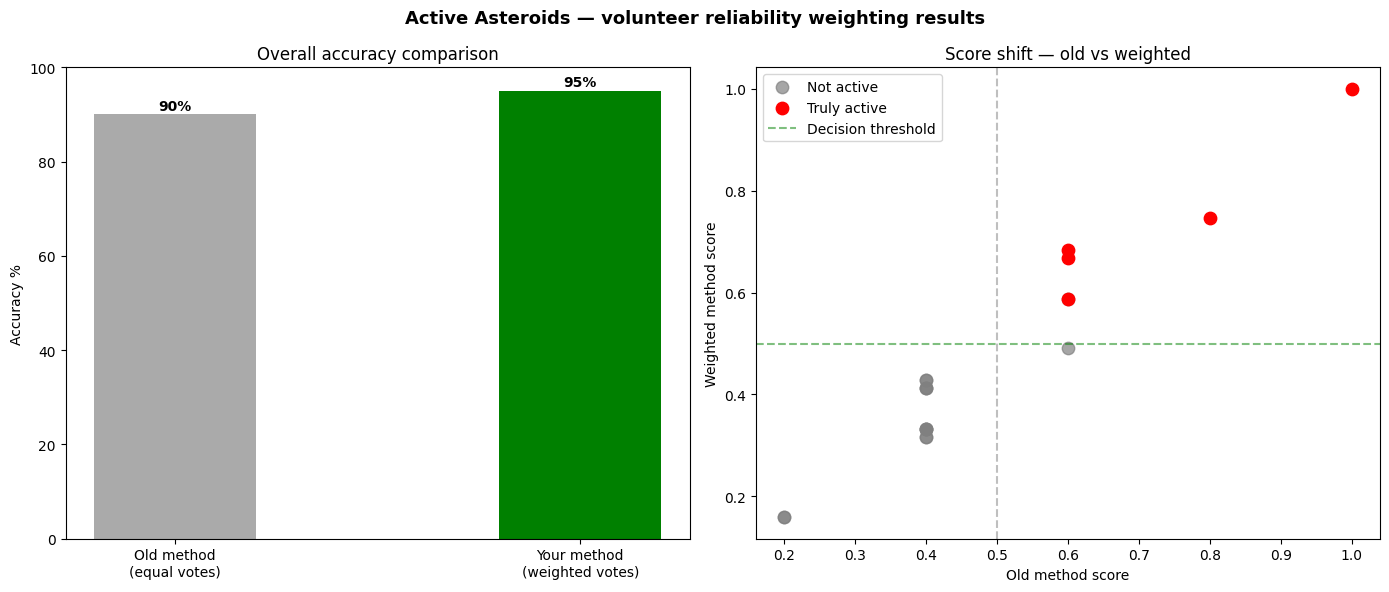

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — accuracy comparison
methods = ['Old method\n(equal votes)', 'Your method\n(weighted votes)']
accuracies = [old_accuracy * 100, new_accuracy * 100]
colors = ['#aaaaaa', 'green']

bars = ax1.bar(methods, accuracies, color=colors, width=0.4)
ax1.set_ylim(0, 100)
ax1.set_ylabel('Accuracy %')
ax1.set_title('Overall accuracy comparison')
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc:.0f}%',
             ha='center', fontweight='bold')

# Chart 2 — score comparison per asteroid
active = df_results[df_results['truly_active'] == True]
inactive = df_results[df_results['truly_active'] == False]

ax2.scatter(inactive['old_score'], inactive['weighted_score'],
            color='gray', label='Not active', s=80, alpha=0.7)
ax2.scatter(active['old_score'], active['weighted_score'],
            color='red', label='Truly active', s=80, zorder=5)
ax2.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Decision threshold')
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Old method score')
ax2.set_ylabel('Weighted method score')
ax2.set_title('Score shift — old vs weighted')
ax2.legend()

plt.suptitle('Active Asteroids — volunteer reliability weighting results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()